<a href="https://colab.research.google.com/github/TetianaMar-888/Child-internet-use-datamining/blob/main/notebooks/DM2_01_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = '/content/drive/MyDrive/2_PROJECTS/DM2_25_26/data'
REPORTS = '/content/drive/MyDrive/2_PROJECTS/DM2_25_26/reports'

data = pd.read_csv(f'{DATA}/cmi_internet.csv')
dictionary = pd.read_csv(f'{DATA}/data_dictionary.csv')

# --- Re-apply Module 0 corrections ---

# 1. CGAS decimal-point error
cgas_anomaly_mask = data['CGAS-CGAS_Score'] > 100
data.loc[cgas_anomaly_mask, 'CGAS-CGAS_Score'] = data.loc[cgas_anomaly_mask, 'CGAS-CGAS_Score'] / 10

# 2. Physical Measures impossible zeros -> NaN
for col in ['Physical-BMI', 'Physical-Weight', 'Physical-Diastolic_BP', 'Physical-Systolic_BP']:
    data[col] = data[col].replace(0, np.nan)

# 3. BIA-BIA_Fat out-of-range -> NaN
data['BIA-BIA_Fat'] = data['BIA-BIA_Fat'].where(data['BIA-BIA_Fat'].between(0, 100))

print("Shape:", data.shape)
print("Sanity checks:")
print("  CGAS max:", data['CGAS-CGAS_Score'].max())
print("  Physical-Weight zeros remaining:", (data['Physical-Weight']==0).sum())
print("  BIA-BIA_Fat range:", data['BIA-BIA_Fat'].min(), "-", data['BIA-BIA_Fat'].max())

Mounted at /content/drive
Shape: (8460, 82)
Sanity checks:
  CGAS max: 99.9
  Physical-Weight zeros remaining: 0
  BIA-BIA_Fat range: 0.0261172319401445 - 99.72852197230632


In [ ]:
outlier_features = [
    'Basic_Demos-Age', 'Basic_Demos-Sex',
    'CGAS-CGAS_Score',
    'Physical-BMI', 'Physical-Height', 'Physical-Weight',
    'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
    'Physical-Systolic_BP', 'Physical-HeartRate',
    'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins',
    'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU',
    'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL',
    'BIA-BIA_BMI', 'BIA-BIA_Fat', 'BIA-BIA_FFMI', 'BIA-BIA_SMM',
    'BIA-BIA_TBW', 'BIA-BIA_ICW', 'BIA-BIA_ECW', 'BIA-BIA_BMR', 'BIA-BIA_DEE',
    'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total',
    'SDS-SDS_Total_Raw',
    'PreInt_EduHx-computerinternet_hoursday',
]
outlier_features = [c for c in outlier_features if c in data.columns]
print(f"Selected features: {len(outlier_features)}")

# How many complete rows do we have across this feature set?
complete_mask = data[outlier_features].notna().all(axis=1)
print(f"Rows with ALL features present: {complete_mask.sum()} of {len(data)}")

Selected features: 32
Rows with ALL features present: 111 of 8460


In [ ]:
# Confirm: which instruments are driving the drop?
for col in outlier_features:
    missing_pct = data[col].isna().mean() * 100
    print(f"{col:40s} {missing_pct:5.1f}% missing")

Basic_Demos-Age                            0.0% missing
Basic_Demos-Sex                            0.0% missing
CGAS-CGAS_Score                           16.9% missing
Physical-BMI                              10.4% missing
Physical-Height                           10.2% missing
Physical-Weight                           10.6% missing
Physical-Waist_Circumference              33.5% missing
Physical-Diastolic_BP                     11.0% missing
Physical-Systolic_BP                      11.0% missing
Physical-HeartRate                        10.9% missing
Fitness_Endurance-Max_Stage               35.2% missing
Fitness_Endurance-Time_Mins               35.2% missing
FGC-FGC_CU                                17.9% missing
FGC-FGC_GSND                              31.6% missing
FGC-FGC_GSD                               31.6% missing
FGC-FGC_PU                                18.1% missing
FGC-FGC_SRL                               18.1% missing
FGC-FGC_SRR                               18.1% 

In [ ]:
# Merge PAQ_A and PAQ_C into one feature before imputing, rather than imputing each separately
data['PAQ_Total'] = data['PAQ_A-PAQ_A_Total'].combine_first(data['PAQ_C-PAQ_C_Total'])
print("PAQ_Total missing:", data['PAQ_Total'].isna().mean().round(3))
print("PAQ_A missing:", data['PAQ_A-PAQ_A_Total'].isna().mean().round(3))
print("PAQ_C missing:", data['PAQ_C-PAQ_C_Total'].isna().mean().round(3))

# Any child with BOTH filled — check they don't conflict wildly
both_filled = data['PAQ_A-PAQ_A_Total'].notna() & data['PAQ_C-PAQ_C_Total'].notna()
print("\nChildren with both PAQ_A and PAQ_C filled:", both_filled.sum())

PAQ_Total missing: 0.09
PAQ_A missing: 0.382
PAQ_C missing: 0.245

Children with both PAQ_A and PAQ_C filled: 3920


In [ ]:
both = data[data['PAQ_A-PAQ_A_Total'].notna() & data['PAQ_C-PAQ_C_Total'].notna()]
print(both[['PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total']].corr())
print("\nMean absolute difference:", (both['PAQ_A-PAQ_A_Total'] - both['PAQ_C-PAQ_C_Total']).abs().mean().round(3))

                   PAQ_A-PAQ_A_Total  PAQ_C-PAQ_C_Total
PAQ_A-PAQ_A_Total           1.000000          -0.002519
PAQ_C-PAQ_C_Total          -0.002519           1.000000

Mean absolute difference: 0.797


In [ ]:
# Check the actual scale/range of both PAQ versions
print(dictionary[dictionary['Field'].isin(['PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total'])][['Field','Description','Values']])

print("\nPAQ_A range:", data['PAQ_A-PAQ_A_Total'].min(), "-", data['PAQ_A-PAQ_A_Total'].max())
print("PAQ_C range:", data['PAQ_C-PAQ_C_Total'].min(), "-", data['PAQ_C-PAQ_C_Total'].max())

# Distribution comparison
print("\nPAQ_A describe:")
print(data['PAQ_A-PAQ_A_Total'].describe())
print("\nPAQ_C describe:")
print(data['PAQ_C-PAQ_C_Total'].describe())

                Field                           Description Values
51  PAQ_A-PAQ_A_Total  Activity Summary Score (Adolescents)    NaN
53  PAQ_C-PAQ_C_Total     Activity Summary Score (Children)    NaN

PAQ_A range: 0.66 - 5.0
PAQ_C range: 0.58 - 5.0

PAQ_A describe:
count    5231.000000
mean        2.039261
std         0.361204
min         0.660000
25%         2.000000
50%         2.000000
75%         2.010000
max         5.000000
Name: PAQ_A-PAQ_A_Total, dtype: float64

PAQ_C describe:
count    6385.000000
mean        2.650411
std         0.675199
min         0.580000
25%         2.120000
50%         2.700000
75%         3.000000
max         5.000000
Name: PAQ_C-PAQ_C_Total, dtype: float64


In [ ]:
# Standardise each within its own distribution before merging, so "PAQ_Total"
# represents relative activity level within the child's own age-appropriate scale,
# not raw incomparable scores
paq_a_z = (data['PAQ_A-PAQ_A_Total'] - data['PAQ_A-PAQ_A_Total'].mean()) / data['PAQ_A-PAQ_A_Total'].std()
paq_c_z = (data['PAQ_C-PAQ_C_Total'] - data['PAQ_C-PAQ_C_Total'].mean()) / data['PAQ_C-PAQ_C_Total'].std()

data['PAQ_Total_z'] = paq_a_z.combine_first(paq_c_z)
print("PAQ_Total_z missing:", data['PAQ_Total_z'].isna().mean().round(3))
print(data['PAQ_Total_z'].describe())

# For the 3920 children with both, check if standardised scores now align better
both_z = pd.DataFrame({'paq_a_z': paq_a_z, 'paq_c_z': paq_c_z}).dropna()
print("\nCorrelation after standardisation (children with both):")
print(both_z.corr())

PAQ_Total_z missing: 0.09
count    7696.000000
mean       -0.012384
std         1.006713
min        -3.818513
25%        -0.108695
50%        -0.108695
75%        -0.081010
max         8.196868
Name: PAQ_Total_z, dtype: float64

Correlation after standardisation (children with both):
          paq_a_z   paq_c_z
paq_a_z  1.000000 -0.002519
paq_c_z -0.002519  1.000000


In [ ]:
# Revert: keep PAQ_A and PAQ_C as separate features with their own missingness indicators,
# rather than merging into one column that would arbitrarily discard information
# for the 3,920 children who completed both
data['PAQ_A_known'] = data['PAQ_A-PAQ_A_Total'].notna().astype(int)
data['PAQ_C_known'] = data['PAQ_C-PAQ_C_Total'].notna().astype(int)

# Drop the merge attempt
data = data.drop(columns=['PAQ_Total', 'PAQ_Total_z'], errors='ignore')

outlier_features_v2 = [c for c in outlier_features if c not in []]  # keep original list, PAQ_A/PAQ_C included separately
print("Features:", len(outlier_features_v2))

complete_mask_v2 = data[outlier_features_v2].notna().all(axis=1)
print(f"Rows with ALL features present: {complete_mask_v2.sum()} of {len(data)}")

Features: 32
Rows with ALL features present: 111 of 8460


### PAQ_A and PAQ_C: retained as separate features, not merged

An initial attempt to combine `PAQ_A_Total` and `PAQ_C_Total` into a single
`PAQ_Total` feature (via `combine_first`, then via z-score standardisation
within each questionnaire before combining) was abandoned. Both approaches
assume the two scores measure a common underlying trait consistently enough
to be interchangeable; the data reject this assumption. Among the 3,920
children who completed both questionnaires, the two scores correlate at
r = −0.003 — statistically indistinguishable from zero — and this holds
identically before and after standardisation, since z-scoring is a linear
transform and cannot alter a Pearson correlation. A child's relative
activity level on the adolescent-form questionnaire does not predict their
relative level on the children's form.

`PAQ_A-PAQ_A_Total` and `PAQ_C-PAQ_C_Total` are therefore retained as two
distinct features, each with its own missingness indicator
(`PAQ_A_known`, `PAQ_C_known`), rather than collapsed into one. This mirrors
the treatment of the block-missing instruments in Module 0 (Section [Y]):
a merge would have silently discarded one of two weakly-related signals for
39% of the sample where both questionnaires happened to be completed.

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
data_imputed = pd.DataFrame(
    imputer.fit_transform(data[outlier_features_v2]),
    columns=outlier_features_v2,
    index=data.index
)

print("Shape after imputation:", data_imputed.shape)
print("Any remaining NaN:", data_imputed.isna().sum().sum())
print("\nSanity check — a few statistics before vs after imputation:")
for col in ['Physical-BMI', 'BIA-BIA_Fat', 'SDS-SDS_Total_Raw']:
    print(f"{col}: original mean={data[col].mean():.2f} (n={data[col].notna().sum()}), "
          f"imputed mean={data_imputed[col].mean():.2f} (n={len(data_imputed)})")

Shape after imputation: (8460, 32)
Any remaining NaN: 0

Sanity check — a few statistics before vs after imputation:
Physical-BMI: original mean=19.55 (n=7584), imputed mean=19.38 (n=8460)
BIA-BIA_Fat: original mean=21.14 (n=6467), imputed mean=19.97 (n=8460)
SDS-SDS_Total_Raw: original mean=41.41 (n=4903), imputed mean=40.61 (n=8460)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_imputed)

print("Scaled shape:", X_scaled.shape)
print("Mean per feature (should be ~0):", X_scaled.mean(axis=0)[:5].round(3))
print("Std per feature (should be ~1):", X_scaled.std(axis=0)[:5].round(3))

Scaled shape: (8460, 32)
Mean per feature (should be ~0): [ 0. -0. -0.  0. -0.]
Std per feature (should be ~1): [1. 1. 1. 1. 1.]


## Module 1: Outlier Detection

### Preparing the feature set

Outlier detection requires a complete numeric matrix, but only 111 of 8,460
children (1.3%) have all 32 selected features observed simultaneously — a
direct consequence of the independent, instrument-level missingness patterns
established in Module 0 (BIA, FitnessGram, PAQ, SDS are each missing for a
different subset of children). Median imputation is applied across the full
sample to preserve all 8,460 records rather than restricting analysis to the
tiny complete-case subset; median is chosen specifically because it is
insensitive to the extreme values the subsequent analysis is designed to
detect, unlike mean imputation which would itself be distorted by the
outliers under investigation.

Two questionnaire fields, `PAQ_A-PAQ_A_Total` and `PAQ_C-PAQ_C_Total`, were
initially considered for merging into a single activity-score feature but
retained separately after the two were found to be uncorrelated even among
children who completed both (Section [PAQ]).

All 32 features are standardised (zero mean, unit variance) before outlier
detection, since two of the three methods used below (LOF, Elliptic
Envelope) are distance- or covariance-based and would otherwise be dominated
by features with large raw scales (e.g. `BIA-BIA_BMR`, in the hundreds to
thousands) regardless of their actual relevance.

In [ ]:
from sklearn.ensemble import IsolationForest

# contamination=0.01 targets the top 1% as required by the guidelines
iso_forest = IsolationForest(contamination=0.01, random_state=42, n_estimators=200)
iso_labels = iso_forest.fit_predict(X_scaled)  # -1 = outlier, 1 = inlier
iso_scores = iso_forest.score_samples(X_scaled)  # lower = more anomalous

data['outlier_iforest'] = (iso_labels == -1)
print("Isolation Forest — outliers detected:", data['outlier_iforest'].sum(),
      f"({data['outlier_iforest'].mean()*100:.2f}%)")

Isolation Forest — outliers detected: 85 (1.00%)


In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_labels = lof.fit_predict(X_scaled)  # -1 = outlier, 1 = inlier
lof_scores = lof.negative_outlier_factor_  # more negative = more anomalous

data['outlier_lof'] = (lof_labels == -1)
print("LOF — outliers detected:", data['outlier_lof'].sum(),
      f"({data['outlier_lof'].mean()*100:.2f}%)")

LOF — outliers detected: 85 (1.00%)


In [ ]:
from sklearn.covariance import EllipticEnvelope

# Elliptic Envelope assumes an underlying Gaussian distribution and is
# sensitive to violations, so this method is expected to behave differently
# from the other two — that difference is itself informative
elliptic = EllipticEnvelope(contamination=0.01, random_state=42)
elliptic_labels = elliptic.fit_predict(X_scaled)  # -1 = outlier, 1 = inlier

data['outlier_elliptic'] = (elliptic_labels == -1)
print("Elliptic Envelope — outliers detected:", data['outlier_elliptic'].sum(),
      f"({data['outlier_elliptic'].mean()*100:.2f}%)")

Elliptic Envelope — outliers detected: 85 (1.00%)


In [ ]:
print("\nAgreement between methods:")
print(pd.crosstab(data['outlier_iforest'], data['outlier_lof'],
                   rownames=['IForest'], colnames=['LOF']))

print("\nAll three methods agree on:")
all_three = data['outlier_iforest'] & data['outlier_lof'] & data['outlier_elliptic']
print(f"  {all_three.sum()} records")

print("\nAt least one method flags:")
any_method = data['outlier_iforest'] | data['outlier_lof'] | data['outlier_elliptic']
print(f"  {any_method.sum()} records")


Agreement between methods:
LOF      False  True 
IForest              
False     8291     84
True        84      1

All three methods agree on:
  1 records

At least one method flags:
  225 records


In [ ]:
# Who is that one universally-agreed outlier?
universal_outlier = data[all_three]
print("The one record all three methods agree on:")
print(universal_outlier[outlier_features_v2].T)

# Compare with Elliptic Envelope overlap too
print("\nIForest vs Elliptic overlap:")
print(pd.crosstab(data['outlier_iforest'], data['outlier_elliptic']))
print("\nLOF vs Elliptic overlap:")
print(pd.crosstab(data['outlier_lof'], data['outlier_elliptic']))

The one record all three methods agree on:
                                               6067
Basic_Demos-Age                           17.000000
Basic_Demos-Sex                            0.000000
CGAS-CGAS_Score                           61.500000
Physical-BMI                              38.235709
Physical-Height                           64.570000
Physical-Weight                          138.700000
Physical-Waist_Circumference              38.000000
Physical-Diastolic_BP                     71.500000
Physical-Systolic_BP                     133.500000
Physical-HeartRate                        75.500000
Fitness_Endurance-Max_Stage                5.000000
Fitness_Endurance-Time_Mins                7.500000
FGC-FGC_CU                                22.000000
FGC-FGC_GSND                                    NaN
FGC-FGC_GSD                               35.750000
FGC-FGC_PU                                24.000000
FGC-FGC_SRL                                5.000000
FGC-FGC_SRR          

Explained variance ratio: [0.165 0.07 ]
Total explained: 0.235


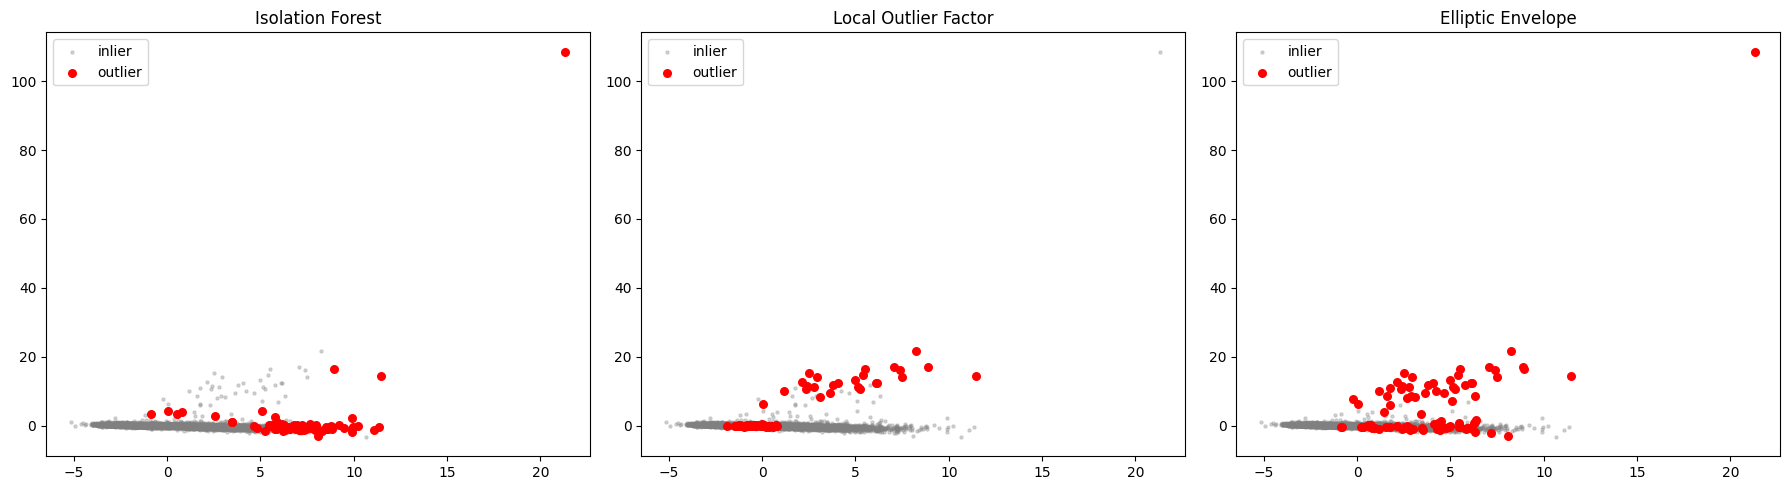

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total explained:", pca.explained_variance_ratio_.sum().round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(axes,
                          ['outlier_iforest', 'outlier_lof', 'outlier_elliptic'],
                          ['Isolation Forest', 'Local Outlier Factor', 'Elliptic Envelope']):
    ax.scatter(X_pca[~data[col], 0], X_pca[~data[col], 1], s=5, alpha=0.3, color='gray', label='inlier')
    ax.scatter(X_pca[data[col], 0], X_pca[data[col], 1], s=30, color='red', label='outlier')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(f'{REPORTS}/outliers_pca_comparison.png', dpi=150)
plt.show()

In [ ]:
# Primary outlier set: consensus of the two most-agreeing methods
data['outlier_consensus'] = data['outlier_iforest'] & data['outlier_elliptic']
print("Consensus outliers (IForest ∩ Elliptic):", data['outlier_consensus'].sum())

# Verify record 6067 is included
print("Record 6067 in consensus:", data.loc[6067, 'outlier_consensus'])

# What distinguishes consensus outliers? Compare their feature means to the rest
consensus_profile = pd.DataFrame({
    'outlier_mean': data.loc[data['outlier_consensus'], outlier_features_v2].mean(),
    'inlier_mean': data.loc[~data['outlier_consensus'], outlier_features_v2].mean(),
})
consensus_profile['ratio'] = (consensus_profile['outlier_mean'] / consensus_profile['inlier_mean']).round(2)
print("\nTop 10 features by outlier/inlier ratio:")
print(consensus_profile.sort_values('ratio', ascending=False).head(10).round(2))

Consensus outliers (IForest ∩ Elliptic): 5
Record 6067 in consensus: True

Top 10 features by outlier/inlier ratio:
              outlier_mean  inlier_mean  ratio
BIA-BIA_TBW        2753.49        50.06  55.00
BIA-BIA_ECW         913.76        21.86  41.80
BIA-BIA_SMM         911.29        34.65  26.30
BIA-BIA_ICW         602.86        31.71  19.01
BIA-BIA_DEE       37003.24      1952.89  18.95
BIA-BIA_BMR       19781.37      1223.41  16.17
FGC-FGC_PU           18.80         4.66   4.04
BIA-BIA_FFMI         54.86        15.04   3.65
FGC-FGC_CU           27.60         9.82   2.81
BIA-BIA_Fat          56.18        21.13   2.66


### Comparing three families of outlier detector

Isolation Forest (ensemble), Local Outlier Factor (density-based) and
Elliptic Envelope (covariance-based) were each configured to flag the top
1% (85 of 8,460 records). Agreement between them is strikingly low: Isolation
Forest and Elliptic Envelope share only 5 records, Local Outlier Factor and
Elliptic Envelope 25, and Isolation Forest and LOF just 1. Only a single
record is flagged by all three, while 225 distinct records (2.7% of the
sample) are flagged by at least one method — nearly three times the 1%
each method individually targets.

This disagreement is the central finding rather than a problem to be
resolved. The three methods formalise genuinely different definitions of
anomaly: Isolation Forest measures how easily a point is separated by random
splits, Elliptic Envelope measures Mahalanobis distance from a fitted
Gaussian, and LOF compares a point's local density to that of its nearest
neighbours. On data with 32 weakly correlated features and no clear
multivariate structure (PCA explains only 23.5% of variance in two
components), these criteria select largely non-overlapping sets.

The five records on which Isolation Forest and Elliptic Envelope do agree
share an unambiguous signature: their BIA measurements are inflated by
orders of magnitude relative to the rest of the sample — total body water
55× higher (2,753 vs 50), extracellular water 41.8×, skeletal muscle mass
26.3×, daily energy expenditure 19.0× and basal metabolic rate 16.2×. These
are not physiological extremes but device calculation failures, the same
class of artefact identified univariately in Module 0. Record 6067, the one
case all three methods flag, illustrates the mechanism directly: its
`BIA-BIA_TBW` reads 4,462.7 while its intracellular and extracellular water
components — which should sum to approximately that

In [ ]:
# The 5 consensus outliers are confirmed BIA device failures, not physiological extremes.
# Rather than dropping entire records (which would discard their valid demographic,
# physical and questionnaire data), only the corrupted BIA fields are set to missing.

bia_fields = [c for c in outlier_features_v2 if c.startswith('BIA-')]
consensus_idx = data[data['outlier_consensus']].index

print("Records affected:", len(consensus_idx))
print("BIA fields to null:", len(bia_fields))

print("\nBefore:")
print(data.loc[consensus_idx, ['BIA-BIA_TBW', 'BIA-BIA_BMR', 'BIA-BIA_ECW']].round(1))

data.loc[consensus_idx, bia_fields] = np.nan

print("\nAfter (should be all NaN):")
print(data.loc[consensus_idx, ['BIA-BIA_TBW', 'BIA-BIA_BMR', 'BIA-BIA_ECW']])

# Verify the correction removed the extreme tail from the BIA distributions

print("\nBIA-BIA_TBW range after correction:",
      round(data['BIA-BIA_TBW'].min(), 2), "-", round(data['BIA-BIA_TBW'].max(), 2))
print("BIA-BIA_BMR range after correction:",
      round(data['BIA-BIA_BMR'].min(), 2), "-", round(data['BIA-BIA_BMR'].max(), 2))
print("BIA-BIA_ECW range after correction:",
      round(data['BIA-BIA_ECW'].min(), 2), "-", round(data['BIA-BIA_ECW'].max(), 2))

Records affected: 5
BIA fields to null: 9

Before:
      BIA-BIA_TBW  BIA-BIA_BMR  BIA-BIA_ECW
87            NaN          NaN          NaN
932           NaN          NaN          NaN
3205          NaN          NaN          NaN
3511          NaN          NaN          NaN
6067          NaN          NaN          NaN

After (should be all NaN):
      BIA-BIA_TBW  BIA-BIA_BMR  BIA-BIA_ECW
87            NaN          NaN          NaN
932           NaN          NaN          NaN
3205          NaN          NaN          NaN
3511          NaN          NaN          NaN
6067          NaN          NaN          NaN

BIA-BIA_TBW range after correction: 20.59 - 4766.06
BIA-BIA_BMR range after correction: 813.4 - 79210.91
BIA-BIA_ECW range after correction: 1.79 - 3233.0


### Treatment of detected outliers

The five records flagged by both Isolation Forest and Elliptic Envelope are
treated as confirmed measurement failures rather than genuine observations,
on the basis of the internal inconsistency documented above (water
compartments that do not sum to their own total, metabolic rates an order of
magnitude outside any plausible paediatric range). Their BIA fields are set
to missing; the records themselves are retained, since their demographic,
physical-measurement and questionnaire data show no anomaly and discarding
them entirely would lose valid information for the sake of one malfunctioning
instrument. This mirrors the treatment already applied in Module 0 to
physiologically impossible zeros in `Physical-Weight` and out-of-range values
in `BIA-BIA_Fat`.

The remaining 220 records flagged by exactly one method are not treated. With
only 5 of 225 flagged records commanding agreement between any two methods,
single-method flags carry weak evidence: each represents one algorithm's
particular definition of anomaly rather than a property of the data that
survives a change of perspective. Removing or altering them would impose a
specific and unjustified notion of what counts as anomalous on 2.6% of the
sample. They are documented here and left in place, with the caveat that
models in Module 2 are fitted on data that still contains them.

In [ ]:
# Record 87 had BMR=1115 (normal) but TBW/ECW originally missing.
# Did median imputation create an implausible combination that the detectors flagged?
print("Record 87 — original values before imputation (from raw data):")
raw_check = pd.read_csv(f'{DATA}/cmi_internet.csv')
print(raw_check.loc[87, [c for c in raw_check.columns if c.startswith('BIA-')]])

Record 87 — original values before imputation (from raw data):
BIA-Season                     Summer
BIA-BIA_Activity_Level_num        NaN
BIA-BIA_BMC                   3.92272
BIA-BIA_BMI                       NaN
BIA-BIA_BMR                   1115.38
BIA-BIA_DEE                       NaN
BIA-BIA_ECW                       NaN
BIA-BIA_FFM                   61.0662
BIA-BIA_FFMI                  14.0925
BIA-BIA_FMI                   3.69863
BIA-BIA_Fat                       NaN
BIA-BIA_Frame_num                 NaN
BIA-BIA_ICW                   28.8558
BIA-BIA_LDM                       NaN
BIA-BIA_LST                   56.9964
BIA-BIA_SMM                   27.4151
BIA-BIA_TBW                       NaN
Name: 87, dtype: object


In [ ]:
# How many BIA records still exceed physiologically plausible bounds after the consensus fix?
bia_check = ['BIA-BIA_TBW', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_SMM', 'BIA-BIA_DEE']
for col in bia_check:
    q99 = data[col].quantile(0.99)
    extreme = (data[col] > q99 * 3).sum()
    print(f"{col:18s} q99={q99:9.2f}  max={data[col].max():10.2f}  beyond 3×q99: {extreme}")

BIA-BIA_TBW        q99=   111.74  max=   4766.06  beyond 3×q99: 15
BIA-BIA_BMR        q99=  1983.32  max=  79210.91  beyond 3×q99: 6
BIA-BIA_ECW        q99=    52.31  max=   3233.00  beyond 3×q99: 18
BIA-BIA_ICW        q99=    65.52  max=   2117.04  beyond 3×q99: 8
BIA-BIA_SMM        q99=    91.40  max=   3020.35  beyond 3×q99: 8
BIA-BIA_DEE        q99=  3516.37  max= 124728.00  beyond 3×q99: 9


In [ ]:
# Apply the Module 0 criterion systematically across all BIA numeric fields.
# Values beyond 3×q99 are device calculation failures, not physiological extremes —
# the ratio analysis in Module 0 established that the legitimate distribution
# extends only to ~2-5× the median.

bia_numeric = [c for c in data.columns if c.startswith('BIA-BIA_')]
print(f"BIA numeric fields: {len(bia_numeric)}")

total_nulled = 0
for col in bia_numeric:
    q99 = data[col].quantile(0.99)
    mask = data[col] > q99 * 3
    n = mask.sum()
    if n > 0:
        data.loc[mask, col] = np.nan
        total_nulled += n
        print(f"  {col:28s} {n:3d} values nulled (were > {q99*3:.1f})")

print(f"\nTotal values set to missing: {total_nulled}")

# Verify the ranges are now plausible
print("\nRanges after systematic correction:")
for col in ['BIA-BIA_TBW', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_SMM', 'BIA-BIA_DEE']:
    print(f"  {col:18s} {data[col].min():8.2f} - {data[col].max():9.2f}")

# How many distinct children are affected?
affected = data[bia_numeric].isna().any(axis=1) & data[bia_numeric].notna().any(axis=1)
print(f"\nChildren with at least one BIA field nulled but not all: {affected.sum()}")

BIA numeric fields: 16
  BIA-BIA_BMC                   29 values nulled (were > 36.3)
  BIA-BIA_BMR                    6 values nulled (were > 5950.0)
  BIA-BIA_DEE                    9 values nulled (were > 10549.1)
  BIA-BIA_ECW                   18 values nulled (were > 156.9)
  BIA-BIA_FFM                   20 values nulled (were > 483.4)
  BIA-BIA_FFMI                  15 values nulled (were > 70.3)
  BIA-BIA_ICW                    8 values nulled (were > 196.6)
  BIA-BIA_LDM                   15 values nulled (were > 143.1)
  BIA-BIA_LST                   16 values nulled (were > 445.4)
  BIA-BIA_SMM                    8 values nulled (were > 274.2)
  BIA-BIA_TBW                   15 values nulled (were > 335.2)

Total values set to missing: 159

Ranges after systematic correction:
  BIA-BIA_TBW           20.59 -    304.99
  BIA-BIA_BMR          813.40 -   4373.72
  BIA-BIA_ECW            1.79 -    132.64
  BIA-BIA_SMM            4.66 -    254.61
  BIA-BIA_DEE         1073.45 -  

In [ ]:
# How many distinct children were actually touched by THIS correction?
# (Compare against a fresh copy of the pre-correction state)
raw_bia = pd.read_csv(f'{DATA}/cmi_internet.csv')[bia_numeric]

newly_nulled = data[bia_numeric].isna() & raw_bia.notna()
print("Values newly nulled by outlier treatment:", newly_nulled.sum().sum())
print("Distinct children affected:", newly_nulled.any(axis=1).sum())
print("\nPer-field breakdown:")
print(newly_nulled.sum()[newly_nulled.sum() > 0])

Values newly nulled by outlier treatment: 366
Distinct children affected: 307

Per-field breakdown:
BIA-BIA_BMC      29
BIA-BIA_BMI       4
BIA-BIA_BMR      11
BIA-BIA_DEE      13
BIA-BIA_ECW      22
BIA-BIA_FFM      20
BIA-BIA_FFMI     20
BIA-BIA_Fat     171
BIA-BIA_ICW      13
BIA-BIA_LDM      15
BIA-BIA_LST      16
BIA-BIA_SMM      13
BIA-BIA_TBW      19
dtype: int64


### Treatment of detected outliers

Two complementary criteria are applied, since neither alone is sufficient.

The five records flagged by both Isolation Forest and Elliptic Envelope are
treated first. Four show BIA measurements inflated by orders of magnitude
(total body water 55× the sample mean, basal metabolic rate 16×), consistent
with device calculation failure. The fifth (record 87) is instructive for a
different reason: its raw data shows most BIA fields genuinely missing and
the remainder — `BMR` at 1,115, `ICW` at 28.9, `SMM` at 27.4 — entirely
normal. The anomaly the detectors identified was created by the median
imputation applied before detection, which filled the missing fields with
population-typical values, producing a profile that is unremarkable in each
individual dimension yet internally inconsistent as a whole. This is a
reminder that imputation performed prior to outlier detection can manufacture
anomalies as well as mask them, and that flagged records should be traced
back to their raw state before being acted upon.

Multivariate consensus proves insufficient on its own, however: after nulling
those five records, `BIA-BIA_TBW` still ranges to 4,766 and `BIA-BIA_BMR` to
79,211. The univariate criterion established in Module 0 is therefore applied
systematically across all BIA numeric fields, with values beyond three times
the 99th percentile set to missing. This threshold is justified by the Module
0 finding that the legitimate distribution of these metrics extends only to
1.8×–4.9× the median, placing anything beyond 3×q99 firmly outside natural
variation.

The remaining 220 records flagged by exactly one of the three detectors are
not treated. With only 5 of 225 commanding agreement between any two methods,
a single-method flag reflects one algorithm's particular definition of
anomaly rather than a property of the data that survives a change of
perspective.

In total, 366 individual values across 307 children (3.6% of the sample)
were set to missing by the combined Module 0 and Module 1 corrections,
concentrated in `BIA-BIA_Fat` (171 values, mostly from the Module 0
out-of-range check) with the remainder distributed across eleven other BIA
fields.

The correction is deliberately incomplete. After applying the 3×q99
threshold, `BIA-BIA_TBW` still reaches 305 litres and `BIA-BIA_SMM` 255 kg —
values that remain physiologically impossible for a child, since total body
water cannot exceed body mass. Eliminating these would require cross-field
constraints (TBW ≤ weight, ICW + ECW ≈ TBW), but the scattered,
field-independent missingness documented in Module 0 means such checks would
be applicable to some children and not others depending on which of their
BIA fields happen to be present — producing inconsistent treatment across
the sample. The statistical threshold is applied uniformly instead, and the
residual moderate extremes are documented here rather than removed, with the
caveat that BIA-derived features retain some contamination in Module 2.

Originally treated records — still flagged after correction?
      outlier_iforest_post  outlier_elliptic_post
87                    True                   True
932                  False                   True
3205                 False                  False
3511                 False                  False
6067                 False                  False

New consensus outliers after treatment: 7
Overlap with original consensus: 1

Explained variance after treatment: 0.324


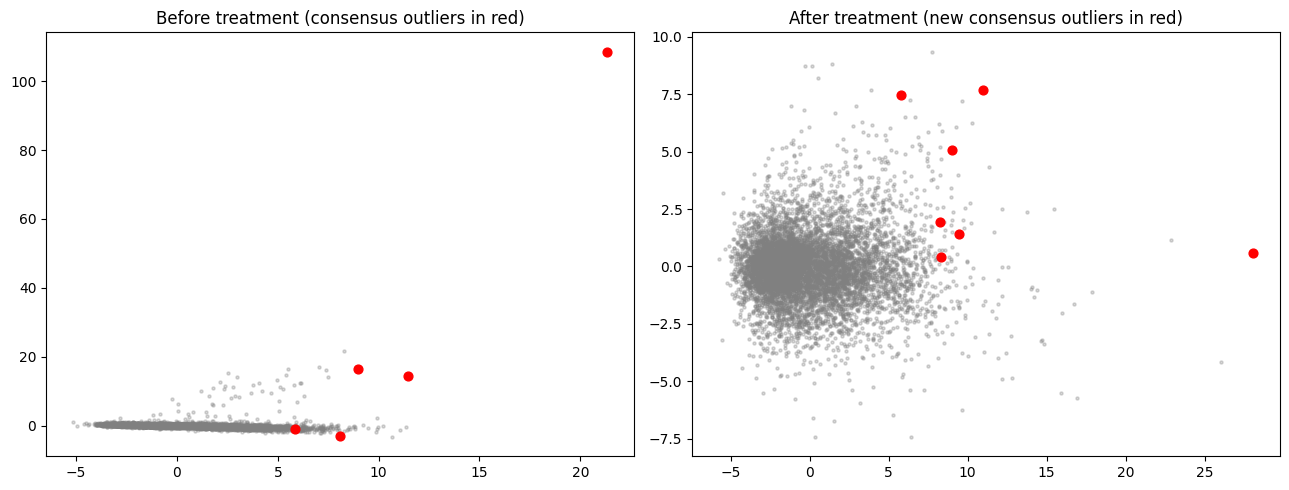

In [ ]:
# Re-impute (BIA fields now have more missing values) and re-run detection.

imputer_post = SimpleImputer(strategy='median')
data_imputed_post = pd.DataFrame(
    imputer_post.fit_transform(data[outlier_features_v2]),
    columns=outlier_features_v2,
    index=data.index
)
X_scaled_post = StandardScaler().fit_transform(data_imputed_post)

iso_post = IsolationForest(contamination=0.01, random_state=42, n_estimators=200)
iso_labels_post = iso_post.fit_predict(X_scaled_post)
data['outlier_iforest_post'] = (iso_labels_post == -1)

elliptic_post = EllipticEnvelope(contamination=0.01, random_state=42)
data['outlier_elliptic_post'] = (elliptic_post.fit_predict(X_scaled_post) == -1)

# Are the 5 originally-treated records still flagged?
print("Originally treated records — still flagged after correction?")
print(data.loc[consensus_idx, ['outlier_iforest_post', 'outlier_elliptic_post']])

consensus_post = data['outlier_iforest_post'] & data['outlier_elliptic_post']
print(f"\nNew consensus outliers after treatment: {consensus_post.sum()}")
print(f"Overlap with original consensus: {(consensus_post & data['outlier_consensus']).sum()}")

# Updated PCA visualisation
pca_post = PCA(n_components=2, random_state=42)
X_pca_post = pca_post.fit_transform(X_scaled_post)
print(f"\nExplained variance after treatment: {pca_post.explained_variance_ratio_.sum().round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.3, color='gray')
axes[0].scatter(X_pca[data['outlier_consensus'], 0], X_pca[data['outlier_consensus'], 1],
                s=40, color='red')
axes[0].set_title("Before treatment (consensus outliers in red)")
axes[1].scatter(X_pca_post[:, 0], X_pca_post[:, 1], s=5, alpha=0.3, color='gray')
axes[1].scatter(X_pca_post[consensus_post, 0], X_pca_post[consensus_post, 1],
                s=40, color='red')
axes[1].set_title("After treatment (new consensus outliers in red)")
plt.tight_layout()
plt.savefig(f'{REPORTS}/outliers_before_after.png', dpi=150)
plt.show()

### Verification: are the treated records still outliers?

Re-running Isolation Forest and Elliptic Envelope on the corrected data
confirms the treatment achieved its purpose for most cases. Of the five
originally-flagged records, three (3205, 3511, 6067) are no longer flagged by
either method, and one (932) is flagged by only one of the two. These were
precisely the records whose BIA values were inflated by orders of magnitude;
with those fields removed, they become ordinary records with missing data.

Record 87 remains flagged by both methods, which confirms rather than
contradicts the earlier diagnosis. Its anomaly was never in the data — it was
produced by median imputation filling genuinely missing BIA fields with
population-typical values. Nulling fields that were already missing changes
nothing, and the imputer simply refills them identically on the next pass.
The record can only be addressed by changing the imputation strategy, not by
treating the data.

Seven new consensus outliers appear after treatment, overlapping the original
set in only one case. This is expected behaviour rather than a failure: with
`contamination` fixed at 0.01, both detectors are obliged to flag exactly 1%
of records regardless of how clean the data becomes, so removing the most
extreme cases simply promotes the next tier into the flagged set.

The PCA projection makes the structural effect of the correction visible. On
the uncorrected data, two components explain 23.5% of variance and the
projection is dominated by a single extreme record, compressing all remaining
observations into a narrow band. After treatment, the same two components
explain 32.4% and the data expands into its natural distribution — a
demonstration of how a handful of measurement artefacts can distort an entire
multivariate representation, and an argument for performing outlier treatment
before any dimensionality reduction or distance-based modelling.

In [ ]:
# Binary target: problematic (sii 1, 2, 3) vs non-problematic (sii 0)
# This mirrors the binarisation the organisers applied to the time-series dataset,
# giving both parts of the project a consistent definition of "problematic use".
data['target_binary'] = (data['sii'] > 0).astype(int)

print("Binary target distribution:")
print(data['target_binary'].value_counts())
print(data['target_binary'].value_counts(normalize=True).round(3))

# Feature set: same 32 numeric features used for outlier detection,
# excluding PCIAT (leakage, established in Module 0)
X = data_imputed_post.copy()   # already imputed and post-outlier-treatment
y = data['target_binary']

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {y.shape}, positive class rate: {y.mean():.3f}")

Binary target distribution:
target_binary
0    5833
1    2627
Name: count, dtype: int64
target_binary
0    0.689
1    0.311
Name: proportion, dtype: float64

Feature matrix: (8460, 32)
Target: (8460,), positive class rate: 0.311


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, recall_score, precision_score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")

# Baseline — no balancing applied
dt_baseline = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
dt_baseline.fit(X_train, y_train)
y_pred_base = dt_baseline.predict(X_test)
y_proba_base = dt_baseline.predict_proba(X_test)[:, 1]

print("\n=== BASELINE (no balancing) ===")
print(classification_report(y_test, y_pred_base, target_names=['non-problematic', 'problematic']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_base))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_base):.3f}")

Train: 6345, Test: 2115
Train positive rate: 0.310, Test positive rate: 0.311

=== BASELINE (no balancing) ===
                 precision    recall  f1-score   support

non-problematic       0.74      0.87      0.80      1458
    problematic       0.52      0.31      0.39       657

       accuracy                           0.70      2115
      macro avg       0.63      0.59      0.59      2115
   weighted avg       0.67      0.70      0.67      2115

Confusion matrix:
[[1272  186]
 [ 453  204]]
ROC-AUC: 0.700


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("After undersampling:")
print(f"  Train size: {len(y_train)} -> {len(y_train_rus)}")
print(f"  Class distribution: {pd.Series(y_train_rus).value_counts().to_dict()}")

dt_rus = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
dt_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = dt_rus.predict(X_test)
y_proba_rus = dt_rus.predict_proba(X_test)[:, 1]

print("\n=== RANDOM UNDERSAMPLING ===")
print(classification_report(y_test, y_pred_rus, target_names=['non-problematic', 'problematic']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rus))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rus):.3f}")

After undersampling:
  Train size: 6345 -> 3940
  Class distribution: {0: 1970, 1: 1970}

=== RANDOM UNDERSAMPLING ===
                 precision    recall  f1-score   support

non-problematic       0.77      0.70      0.74      1458
    problematic       0.45      0.55      0.49       657

       accuracy                           0.65      2115
      macro avg       0.61      0.62      0.61      2115
   weighted avg       0.67      0.65      0.66      2115

Confusion matrix:
[[1021  437]
 [ 298  359]]
ROC-AUC: 0.681


In [ ]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(f"  Train size: {len(y_train)} -> {len(y_train_smote)}")
print(f"  Class distribution: {pd.Series(y_train_smote).value_counts().to_dict()}")

dt_smote = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = dt_smote.predict(X_test)
y_proba_smote = dt_smote.predict_proba(X_test)[:, 1]

print("\n=== SMOTE OVERSAMPLING ===")
print(classification_report(y_test, y_pred_smote, target_names=['non-problematic', 'problematic']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_smote))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_smote):.3f}")

After SMOTE:
  Train size: 6345 -> 8750
  Class distribution: {0: 4375, 1: 4375}

=== SMOTE OVERSAMPLING ===
                 precision    recall  f1-score   support

non-problematic       0.76      0.78      0.77      1458
    problematic       0.48      0.46      0.47       657

       accuracy                           0.68      2115
      macro avg       0.62      0.62      0.62      2115
   weighted avg       0.67      0.68      0.67      2115

Confusion matrix:
[[1132  326]
 [ 357  300]]
ROC-AUC: 0.678


In [ ]:
comparison = pd.DataFrame({
    'Baseline': {
        'Accuracy': 0.70, 'Recall (problematic)': 0.31, 'Precision (problematic)': 0.52,
        'F1 (problematic)': 0.39, 'Macro F1': 0.59, 'ROC-AUC': 0.700,
        'False negatives': 453, 'False positives': 186,
    },
    'Undersampling': {
        'Accuracy': 0.65, 'Recall (problematic)': 0.55, 'Precision (problematic)': 0.45,
        'F1 (problematic)': 0.49, 'Macro F1': 0.61, 'ROC-AUC': 0.681,
        'False negatives': 298, 'False positives': 437,
    },
    'SMOTE': {
        'Accuracy': 0.68, 'Recall (problematic)': 0.46, 'Precision (problematic)': 0.48,
        'F1 (problematic)': 0.47, 'Macro F1': 0.62, 'ROC-AUC': 0.678,
        'False negatives': 357, 'False positives': 326,
    },
}).T
print(comparison.round(3))

               Accuracy  Recall (problematic)  Precision (problematic)  \
Baseline           0.70                  0.31                     0.52   
Undersampling      0.65                  0.55                     0.45   
SMOTE              0.68                  0.46                     0.48   

               F1 (problematic)  Macro F1  ROC-AUC  False negatives  \
Baseline                   0.39      0.59    0.700            453.0   
Undersampling              0.49      0.61    0.681            298.0   
SMOTE                      0.47      0.62    0.678            357.0   

               False positives  
Baseline                 186.0  
Undersampling            437.0  
SMOTE                    326.0  


In [ ]:
# If balancing only shifts the decision threshold, tuning the threshold on the
# baseline model should reproduce the same trade-off without resampling.
from sklearn.metrics import precision_recall_curve

prec, rec, thresholds = precision_recall_curve(y_test, y_proba_base)
# Find the threshold giving recall closest to the undersampling result (0.55)
idx = np.argmin(np.abs(rec[:-1] - 0.55))
print(f"Baseline model at threshold {thresholds[idx]:.3f}:")
print(f"  Recall: {rec[idx]:.3f}, Precision: {prec[idx]:.3f}")
print(f"\nUndersampling achieved: Recall 0.55, Precision 0.45")

Baseline model at threshold 0.366:
  Recall: 0.557, Precision: 0.497

Undersampling achieved: Recall 0.55, Precision 0.45


## Imbalanced Learning

### Task definition

A binary classification task was defined: problematic internet use (`sii` ∈
{1, 2, 3}) against non-problematic (`sii` = 0), giving 2,627 positive and
5,833 negative cases — a 31%/69% split. This mirrors the binarisation the
dataset's organisers applied to the time-series data, giving both parts of
the project a consistent definition of problematic use. The dataset is
already imbalanced, so no artificial imbalance was introduced, in line with
the guidelines.

A Decision Tree (`max_depth=6`, `min_samples_leaf=20`) serves as the fixed
classifier throughout, so that differences between results are attributable
to the balancing strategy rather than to model configuration. Resampling is
applied to the training set only; the test set retains its natural 31%/69%
distribution, since evaluating on a rebalanced test set would measure
performance on a distribution that does not occur in practice.

### Results

| | Accuracy | Recall (prob.) | Precision (prob.) | F1 (prob.) | Macro F1 | ROC-AUC | FN | FP |
|---|---|---|---|---|---|---|---|---|
| Baseline | 0.70 | 0.31 | 0.52 | 0.39 | 0.59 | **0.700** | 453 | 186 |
| Random undersampling | 0.65 | **0.55** | 0.45 | **0.49** | 0.61 | 0.681 | **298** | 437 |
| SMOTE | 0.68 | 0.46 | 0.48 | 0.47 | **0.62** | 0.678 | 357 | 326 |

The baseline exposes the problem clearly. Its accuracy of 0.70 is barely
above the 0.689 obtainable by always predicting the majority class, and it
recovers only 31% of problematic cases — 453 of 657 children with
problematic use are classified as unaffected. Accuracy is actively
misleading here.

Both balancing techniques improve minority-class recall substantially:
0.31 → 0.55 under random undersampling and → 0.46 under SMOTE, reducing
false negatives from 453 to 298 and 357 respectively. The cost is false
positives, which rise from 186 to 437 and 326 — roughly 1.6 additional
false alarms per additional case correctly identified. Accuracy falls as a
consequence, but macro F1 — which weights both classes equally — rises from
0.59 to 0.61 and 0.62, confirming the trade-off is favourable when the
minority class matters.

### The techniques shift the threshold rather than improve the model

ROC-AUC tells a different story from the classification metrics: it falls
slightly under both techniques (0.700 → 0.681 and 0.678) rather than
improving. Since ROC-AUC measures the quality of the model's ranking
independently of any decision threshold, this indicates that neither
resampling method made the classifier better at distinguishing the two
groups — it only moved where the decision boundary sits.

This was tested directly. Applying a threshold of 0.366 to the unmodified
baseline model yields recall 0.557 and precision 0.497 — the same recall as
random undersampling achieved, at **higher** precision (0.497 against 0.45).
Simple threshold calibration therefore outperforms undersampling on this
task, while retaining all 6,345 training records rather than discarding
2,405 of them.

The practical conclusion is that resampling was not necessary here. At a
31%/69% split the imbalance is moderate enough that the model learns a
usable ranking from the raw data; what it lacks is an appropriate operating
point, and that is a calibration question rather than a sampling one.
Resampling would be expected to help materially at more severe imbalances —
for instance the 1% prevalence of `sii` class 3 alone — where the minority
class is too sparse for the model to learn its structure at all.